<a href="https://colab.research.google.com/github/ekttd/most-streamed-spotify-songs/blob/main/most_streamed_spotify_songs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import numpy as np
import pandas as pd
import math

# Загрузка данных

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nelgiriyewithana/top-spotify-songs-2023")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'top-spotify-songs-2023' dataset.
Path to dataset files: /kaggle/input/top-spotify-songs-2023


In [3]:
df = pd.read_csv('/kaggle/input/top-spotify-songs-2023/spotify-2023.csv',encoding='ISO-8859-1')
df.head()

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,144,A,Minor,65,23,80,14,63,11,6


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   track_name            953 non-null    object
 1   artist(s)_name        953 non-null    object
 2   artist_count          953 non-null    int64 
 3   released_year         953 non-null    int64 
 4   released_month        953 non-null    int64 
 5   released_day          953 non-null    int64 
 6   in_spotify_playlists  953 non-null    int64 
 7   in_spotify_charts     953 non-null    int64 
 8   streams               953 non-null    object
 9   in_apple_playlists    953 non-null    int64 
 10  in_apple_charts       953 non-null    int64 
 11  in_deezer_playlists   953 non-null    object
 12  in_deezer_charts      953 non-null    int64 
 13  in_shazam_charts      903 non-null    object
 14  bpm                   953 non-null    int64 
 15  key                   858 non-null    ob

In [5]:
df.describe()

,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,in_apple_playlists,in_apple_charts,in_deezer_charts,bpm,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
count,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000,953.00000,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000
mean,1.556139,2018.238195,6.033578,13.930745,5200.124869,12.009444,67.812172,51.908709,2.666317,122.540399,66.96957,51.431270,64.279119,27.057712,1.581322,18.213012,10.131165
std,0.893044,11.116218,3.566435,9.201949,7897.608990,19.575992,86.441493,50.630241,6.035599,28.057802,14.63061,23.480632,16.550526,25.996077,8.409800,13.711223,9.912888
min,1.000000,1930.000000,1.000000,1.000000,31.000000,0.000000,0.000000,0.000000,0.000000,65.000000,23.00000,4.000000,9.000000,0.000000,0.000000,3.000000,2.000000
25%,1.000000,2020.000000,3.000000,6.000000,875.000000,0.000000,13.000000,7.000000,0.000000,100.000000,57.00000,32.000000,53.000000,6.000000,0.000000,10.000000,4.000000
50%,1.000000,2022.000000,6.000000,13.000000,2224.000000,3.000000,34.000000,38.000000,0.000000,121.000000,69.00000,51.000000,66.000000,18.000000,0.000000,12.000000,6.000000
75%,2.000000,2022.000000,9.000000,22.000000,5542.000000,16.000000,88.000000,87.000000,2.000000,140.000000,78.00000,70.000000,77.000000,43.000000,0.000000,24.000000,11.000000
max,8.000000,2023.000000,12.000000,31.000000,52898.000000,147.000000,672.000000,275.000000,58.000000,206.000000,96.00000,97.000000,97.000000,97.000000,91.000000,97.000000,64.000000


# Подготовка данных

Временные атрибуты:


> 1. released_year
2. released_month
3. released_day

Чарты:


> 1. streams
2. in_spotify_playlists
3. in_spotify_charts
4. in_apple_playlists
5. (and similar platform columns)


Музыкальные атрибуты:


> 1. bpm
2. key
3. mode
4. danceability_%
5. energy_%
6. valence_%
7. acousticness_%
8. instrumentalness_%
9. liveness_%
10. speechiness_%





<Axes: xlabel='key'>

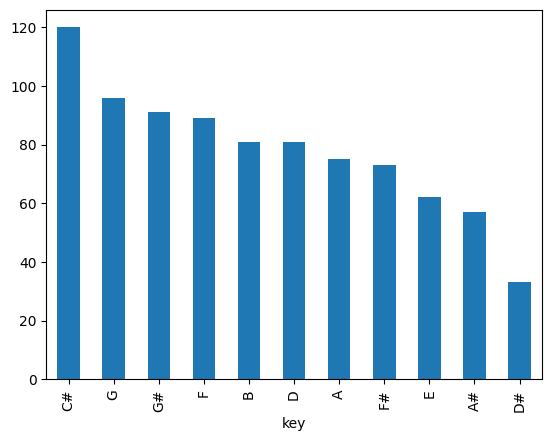

In [7]:
key_data = df['key'].value_counts()


key_data.plot(kind='bar')

Дропаем, не информативно

In [8]:
df = df.drop(columns=["key"])

In [9]:
df["mode"] = df["mode"].map({"Major": 1, "Minor": 0})

# Анализ числовых параметров

array([[<Axes: title={'center': 'bpm'}>,
        <Axes: title={'center': 'danceability_%'}>,
        <Axes: title={'center': 'energy_%'}>],
       [<Axes: title={'center': 'valence_%'}>,
        <Axes: title={'center': 'acousticness_%'}>,
        <Axes: title={'center': 'instrumentalness_%'}>],
       [<Axes: title={'center': 'liveness_%'}>,
        <Axes: title={'center': 'speechiness_%'}>,
        <Axes: title={'center': 'mode'}>]], dtype=object)

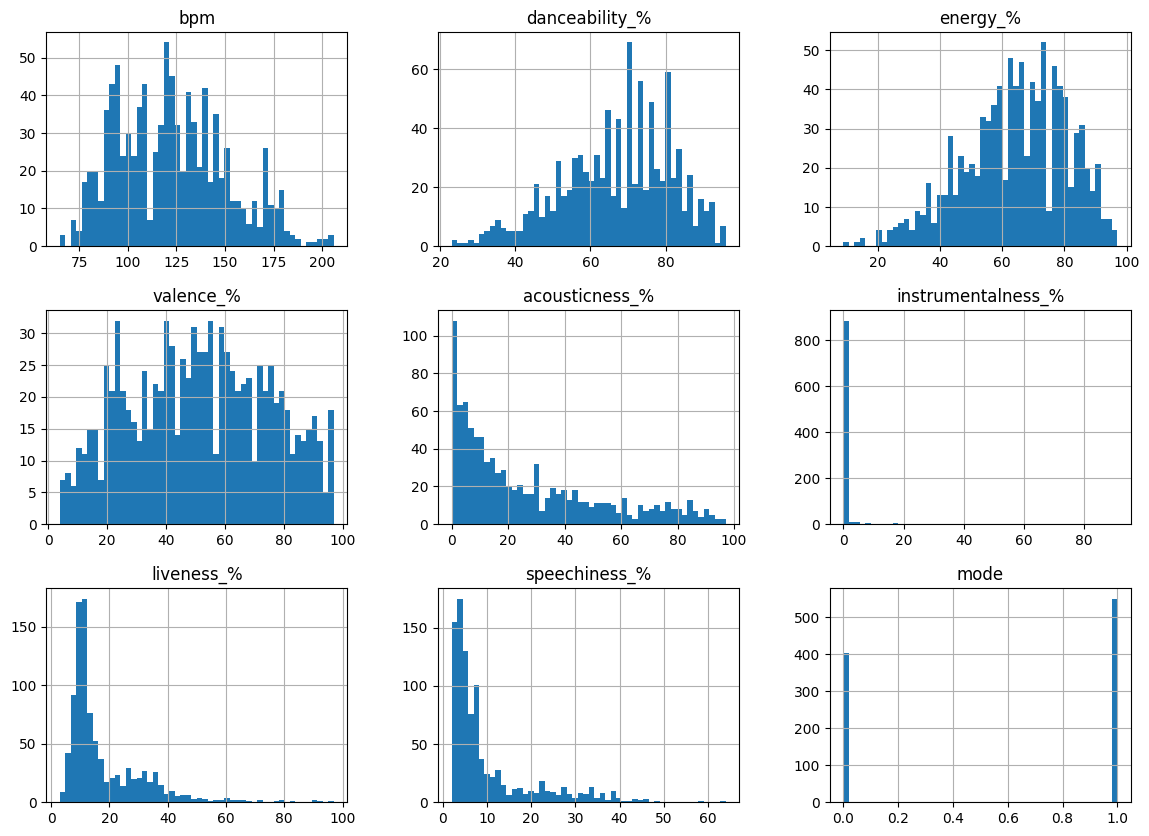

In [27]:
labels = ["bpm", "danceability_%", "energy_%", "valence_%", "acousticness_%", "instrumentalness_%", "liveness_%", "speechiness_%","mode"]

df[labels].hist(bins=50, figsize=(14,10))

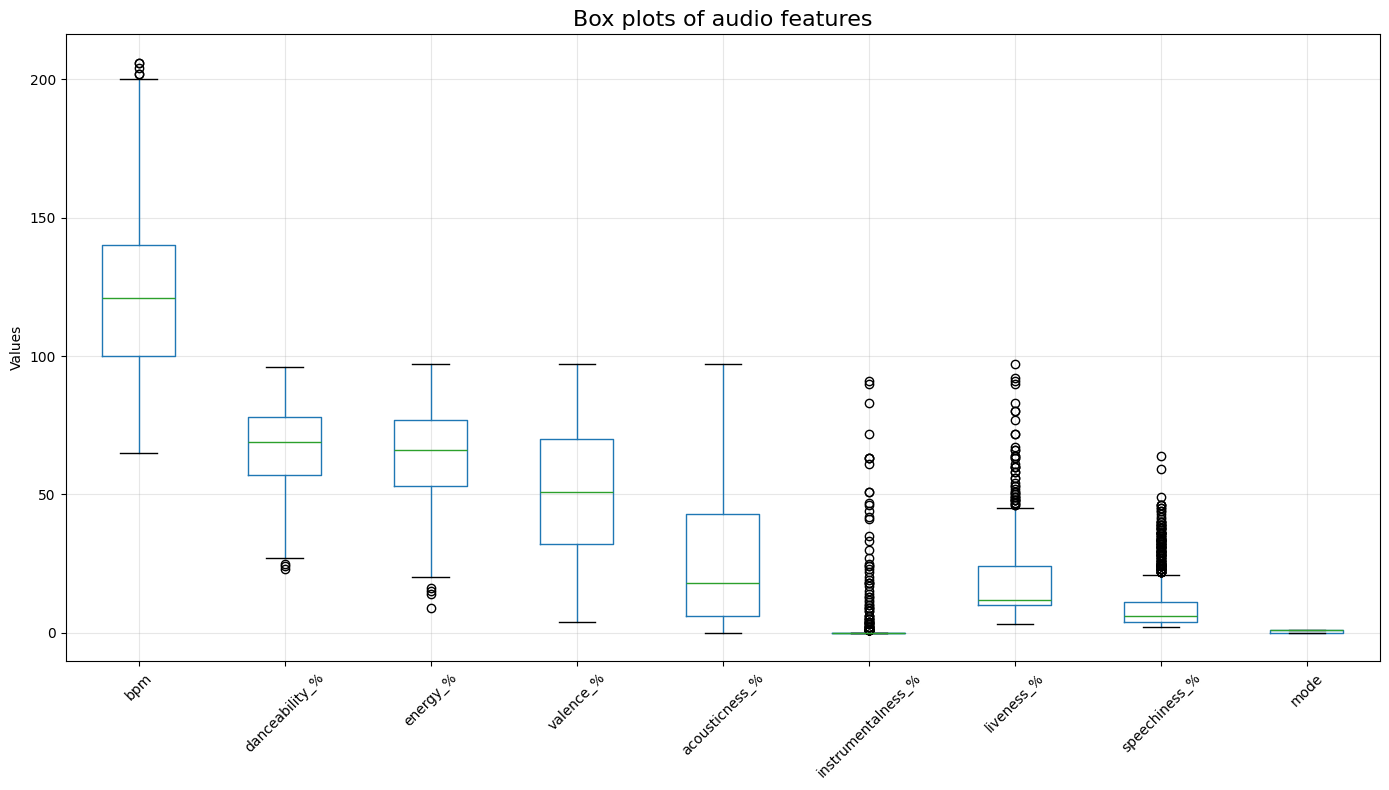

In [21]:
plt.figure(figsize=(14, 8))
df[labels].boxplot()
plt.title('Box plots of audio features', fontsize=16)
plt.xticks(rotation=45)
plt.ylabel('Values')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


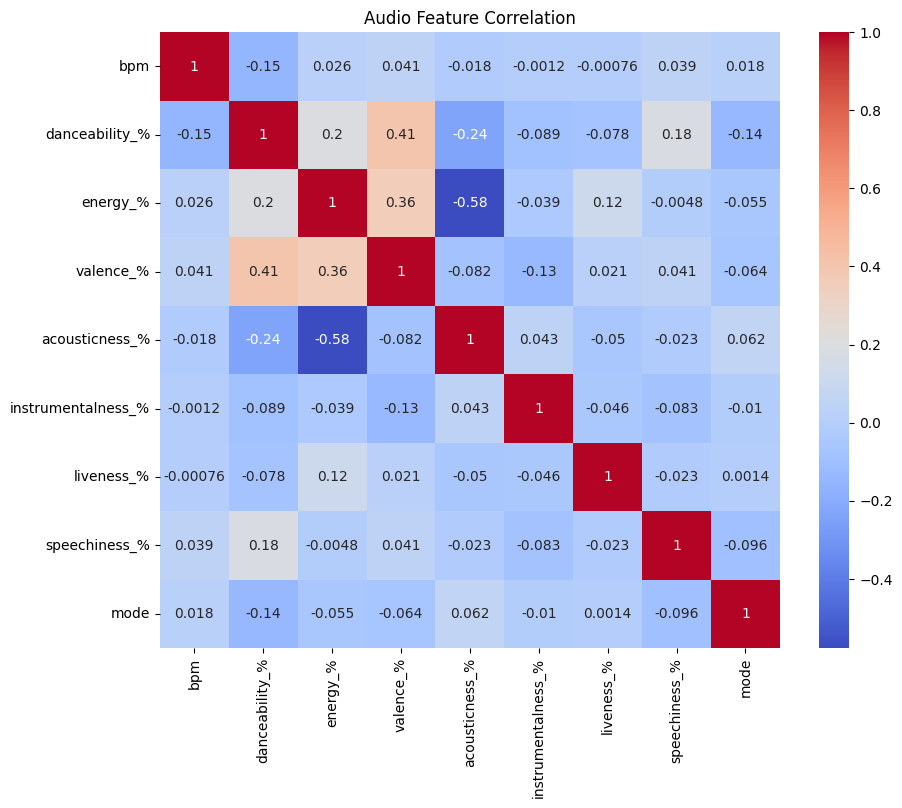

In [19]:
plt.figure(figsize=(10,8))
sns.heatmap(df[labels].corr(), annot=True, cmap="coolwarm")
plt.title("Audio Feature Correlation")
plt.show()